What % of users had at least one event in each month?

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load datasets
users = pd.read_csv("users.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv("subscriptions.csv", parse_dates=["start_date", "end_date"])
events = pd.read_csv("events.csv", parse_dates=["event_date"])

print("Data Loaded Successfully")

Data Loaded Successfully


In [13]:
#Basic data
users['signup_month'] = users['signup_date'].dt.to_period('M')
events['event_month'] = events['event_date'].dt.to_period('M')

In [14]:
#Merging user with events
cohort_data = events.merge(
    users[['user_id', 'signup_month']],
    on='user_id'
)

In [15]:
#Count Active Users Per Cohort
cohort_counts = cohort_data.groupby(
    ['signup_month', 'event_month']
)['user_id'].nunique().reset_index()

In [16]:
#Calculate Cohort Index
cohort_counts['cohort_index'] = (
    cohort_counts['event_month'] - cohort_counts['signup_month']
).apply(lambda x: x.n)

In [17]:
#Create Retention Table
cohort_pivot = cohort_counts.pivot_table(
    index='signup_month',
    columns='cohort_index',
    values='user_id'
)

#Retention %
cohort_size = users.groupby('signup_month')['user_id'].nunique()

retention = cohort_pivot.divide(cohort_size, axis=0)
retention = retention.round(3)

print(retention.head())

cohort_index      0      1      2      3      4      5      6
signup_month                                                 
2026-01       0.689  0.880  0.910  0.922  0.940  0.838  0.671
2026-02       0.648  0.887  0.887  0.931  0.918  0.899  0.541
2026-03       0.637  0.922  0.922  0.933  0.944  0.888  0.419
2026-04       0.645  0.901  0.919  0.936  0.919  0.913  0.552
2026-05       0.620  0.911  0.930  0.930  0.899  0.930  0.532


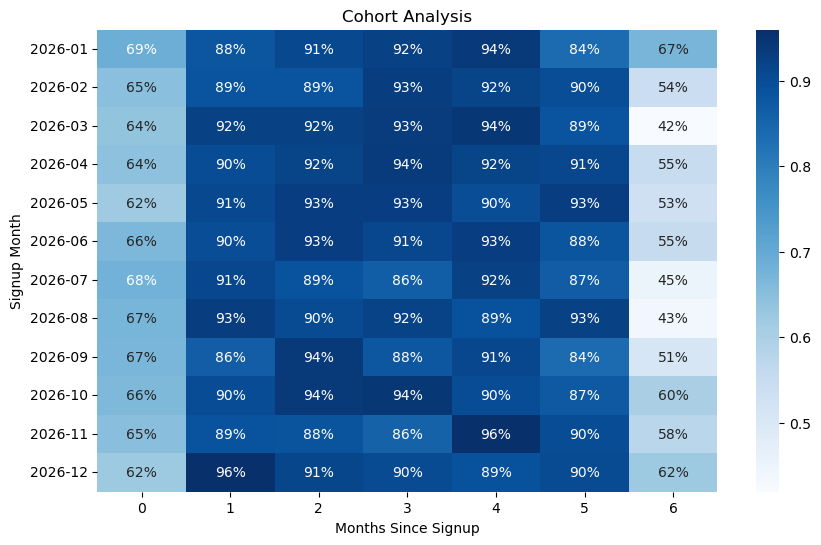

In [18]:
#Visualize Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Analysis")
plt.ylabel("Signup Month")
plt.xlabel("Months Since Signup")
plt.show()

In [19]:
#To exoprt data
retention = retention.reset_index()

retention_melted = retention.melt(
    id_vars=['signup_month'],
    var_name='cohort_index',
    value_name='retention_rate'
)

retention_melted['signup_month'] = retention_melted['signup_month'].astype(str)
retention_melted['cohort_index'] = retention_melted['cohort_index'].astype(int)
retention_melted['retention_rate'] = retention_melted['retention_rate'].astype(float)

print(retention_melted.head())

  signup_month  cohort_index  retention_rate
0      2026-01             0           0.689
1      2026-02             0           0.648
2      2026-03             0           0.637
3      2026-04             0           0.645
4      2026-05             0           0.620


In [20]:
retention_melted.to_csv("cohort_retention.csv", index=False)